In [1]:
import pyreadstat
import pandas as pd
import numpy as np
from pathlib import Path
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns


# Demographic data exploration

The following file aims to visualize and understand better the available data of each participant

In [2]:
df, meta = pyreadstat.read_sav("../object location data/Definitieve data file Data masterthesis GOED.sav")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Columns: 203 entries, ID to Nulscores
dtypes: float64(183), object(20)
memory usage: 63.6+ KB


,ID,sekse,groep,leeftijd,opleiding,RBMT,Stroop_k1,Stroop_k2,Stroop_k3,IF_Stroop,...,filter_$,Diff_score_NT,Diff_score_sRI,Diff_score_dRI,Diff_score_delay,perc_diffscore_NT,perc_diffscore_sRI,perc_diffscore_dRI,perc_diffscore_delay,Nulscores
0,1.0,1.0,0.0,58.0,6.0,55.0,54.0,69.0,96.0,109.0,...,1.0,-0.033016,0.064343,0.054757,-0.118331,-3.301575,6.434347,5.475653,-11.833126,0.0
1,2.0,0.0,0.0,65.0,3.0,NaN,104.0,132.0,350.0,NaN,...,1.0,0.881896,0.515170,0.189972,-0.060228,88.189608,51.516973,18.997194,-6.022760,0.0
2,3.0,0.0,0.0,54.0,5.0,58.0,46.0,100.0,134.0,147.0,...,1.0,0.301841,0.318815,1.085214,0.689474,30.184108,31.881517,108.521447,68.947383,0.0
3,4.0,0.0,0.0,58.0,5.0,54.0,60.0,79.0,110.0,125.0,...,1.0,0.160216,0.197832,0.250294,-0.099256,16.021604,19.783162,25.029393,-9.925591,0.0
4,5.0,0.0,0.0,53.0,3.0,53.0,68.0,80.0,154.0,132.0,...,1.0,-0.006237,0.161231,-0.087561,0.472483,-0.623707,16.123073,-8.756147,47.248282,0.0


In [3]:
df_meta = pd.DataFrame({
    "name": meta.column_names,
    "label": meta.column_labels,
    "measure": [meta.variable_measure.get(col) for col in meta.column_names],
})

In [4]:
# Group variables by type
print(np.unique(df_meta.measure))
nominal_var = [df_meta['name'][i] for i in range(len(df_meta)) if df_meta['measure'][i] == "nominal"]
ordinal_var = [df_meta['name'][i] for i in range(len(df_meta)) if df_meta['measure'][i] == "ordinal"]
scale_var = [df_meta['name'][i] for i in range(len(df_meta)) if df_meta['measure'][i] == "scale"]

['nominal' 'ordinal' 'scale']


In [11]:
ids = [8, 10, 12, 26, 32, 40]

print(
    df[df['ID'].isin(ids)]
    .set_index('ID')
    .T
    .to_string()
)


ID                           8.0          10.0        12.0        26.0        32.0   40.0
sekse                         0.0          0.0         0.0         0.0         0.0    1.0
groep                         0.0          0.0         0.0         1.0         1.0    1.0
leeftijd                     52.0         58.0        57.0        67.0        67.0   58.0
opleiding                     NaN          NaN         4.0         5.0         5.0    5.0
RBMT                          NaN          NaN        53.0         NaN         NaN    NaN
Stroop_k1                    65.0         56.0        67.0        54.0        48.0    NaN
Stroop_k2                    63.0         65.0        72.0        70.0        61.0    NaN
Stroop_k3                   122.0        103.0       121.0       104.0       113.0    NaN
IF_Stroop                     NaN        117.0       119.0       120.0       104.0    NaN
Tscore_IF_Stroop              NaN         56.0        49.0        57.0        46.0    NaN
percent_IF

## . Nominal variables (categorical)

In [5]:
print("Nominal: ", nominal_var)

Nominal:  ['ID', 'sekse', 'groep', 'no_obj.1', 'no_obj.2', 'no_obj.3', 'no_obj.4', 'no_obj.5', 'no_obj.6', 'no_obj.7', 'no_obj.8', 'no_obj.9', 'no_obj.10', 'no_obj.11', 'no_obj.12', 'no_obj.13', 'no_obj.14', 'no_obj.15', 'no_obj.16', 'no_obj.17', 'no_obj.18', 'no_obj.19', 'no_obj.20', 'permut.1', 'permut.2', 'permut.3', 'permut.4', 'permut.5', 'permut.6', 'permut.7', 'permut.8', 'permut.9', 'permut.10', 'permut.11', 'permut.12', 'permut.13', 'permut.14', 'permut.15', 'permut.16', 'permut.17', 'permut.18', 'permut.19', 'permut.20', 'subst.1', 'subst.2', 'subst.3', 'subst.4', 'subst.5', 'subst.6', 'subst.7', 'subst.8', 'subst.9', 'subst.10', 'subst.11', 'subst.12', 'subst.13', 'subst.14', 'subst.15', 'subst.16', 'subst.17', 'subst.18', 'subst.19', 'subst.20', 'swap.1', 'swap.2', 'swap.3', 'swap.4', 'swap.5', 'swap.6', 'swap.7', 'swap.8', 'swap.9', 'swap.10', 'swap.11', 'swap.12', 'swap.13', 'swap.14', 'swap.15', 'swap.16', 'swap.17', 'swap.18', 'swap.19', 'swap.20', 'perc_inc.1', 'perc_i

In [6]:
df_nominal = df[nominal_var]
desc = df_nominal.describe().T

desc["n_unique"] = df_nominal.nunique()
missing_codes = [9999, 9999.00, 8888]
desc["n_missing"] = df_nominal.replace(missing_codes, np.nan).isna().sum()

with pd.option_context('display.max_rows', None):
    display(desc)


,count,mean,std,min,25%,50%,75%,max,n_unique,n_missing
ID,40.0,20.500000,11.690452,1.0,10.75,20.5,30.25,40.0,40,0
sekse,40.0,0.275000,0.452203,0.0,0.00,0.0,1.00,1.0,2,0
groep,40.0,0.500000,0.506370,0.0,0.00,0.5,1.00,1.0,2,0
no_obj.1,39.0,2.000000,0.000000,2.0,2.00,2.0,2.00,2.0,1,1
no_obj.2,39.0,2.000000,0.000000,2.0,2.00,2.0,2.00,2.0,1,1
no_obj.3,39.0,2.000000,0.000000,2.0,2.00,2.0,2.00,2.0,1,1
no_obj.4,39.0,10.000000,0.000000,10.0,10.00,10.0,10.00,10.0,1,1
no_obj.5,39.0,10.000000,0.000000,10.0,10.00,10.0,10.00,10.0,1,1
no_obj.6,39.0,10.000000,0.000000,10.0,10.00,10.0,10.00,10.0,1,1
no_obj.7,39.0,10.000000,0.000000,10.0,10.00,10.0,10.00,10.0,1,1


### Binary variables (gender and group)

In [7]:
gender_map = {0: "Man", 1: "Woman"}
group_map = {0: "KS", 1: "HC"}

gender = df["sekse"].map(gender_map)
group = df["groep"].map(group_map)

print("Counts table")
matrix_counts = (pd.crosstab(gender, group))
matrix_counts['Total'] = matrix_counts.sum(axis=1)
total_row = pd.DataFrame(matrix_counts.sum(axis=0)).T
total_row.index = ['Total']
matrix_counts = pd.concat([matrix_counts, total_row])
matrix_counts = matrix_counts.rename_axis(None, axis=1)
display(matrix_counts)

print("Percentatge table")
matrix_pct = pd.crosstab(gender, group, normalize="all") * 100
matrix_pct["Total"] = matrix_pct.sum(axis=1)
total_row = pd.DataFrame(matrix_pct.sum(axis=0)).T
total_row.index = ["Total"]
matrix_pct = pd.concat([matrix_pct, total_row])
matrix_pct = matrix_pct.rename_axis(None, axis=1)
display(matrix_pct.round(2))

Counts table


,HC,KS,Total
Man,14,15,29
Woman,6,5,11
Total,20,20,40


Percentatge table


,HC,KS,Total
Man,35.0,37.5,72.5
Woman,15.0,12.5,27.5
Total,50.0,50.0,100.0


In [8]:
exclude_ids = [8, 10, 12, 26, 32, 40]
df_filtered = df[~df["ID"].isin(exclude_ids)]

gender = df_filtered["sekse"].map(gender_map)
group = df_filtered["groep"].map(group_map)

print("Counts table filtered participants")
matrix_counts = (pd.crosstab(gender, group))
matrix_counts['Total'] = matrix_counts.sum(axis=1)
total_row = pd.DataFrame(matrix_counts.sum(axis=0)).T
total_row.index = ['Total']
matrix_counts = pd.concat([matrix_counts, total_row])
matrix_counts = matrix_counts.rename_axis(None, axis=1)
display(matrix_counts)

print("Percentatge table filtered participants")
matrix_pct = pd.crosstab(gender, group, normalize="all") * 100
matrix_pct["Total"] = matrix_pct.sum(axis=1)
total_row = pd.DataFrame(matrix_pct.sum(axis=0)).T
total_row.index = ["Total"]
matrix_pct = pd.concat([matrix_pct, total_row])
matrix_pct = matrix_pct.rename_axis(None, axis=1)
display(matrix_pct.round(2))

Counts table filtered participants


,HC,KS,Total
Man,12,12,24
Woman,5,5,10
Total,17,17,34


Percentatge table filtered participants


,HC,KS,Total
Man,35.29,35.29,70.59
Woman,14.71,14.71,29.41
Total,50.00,50.00,100.00


## . Ordinal variables (categorical with order)

In [8]:
print("Ordinal: ", ordinal_var)

Ordinal:  ['opleiding']


Unique values:  6


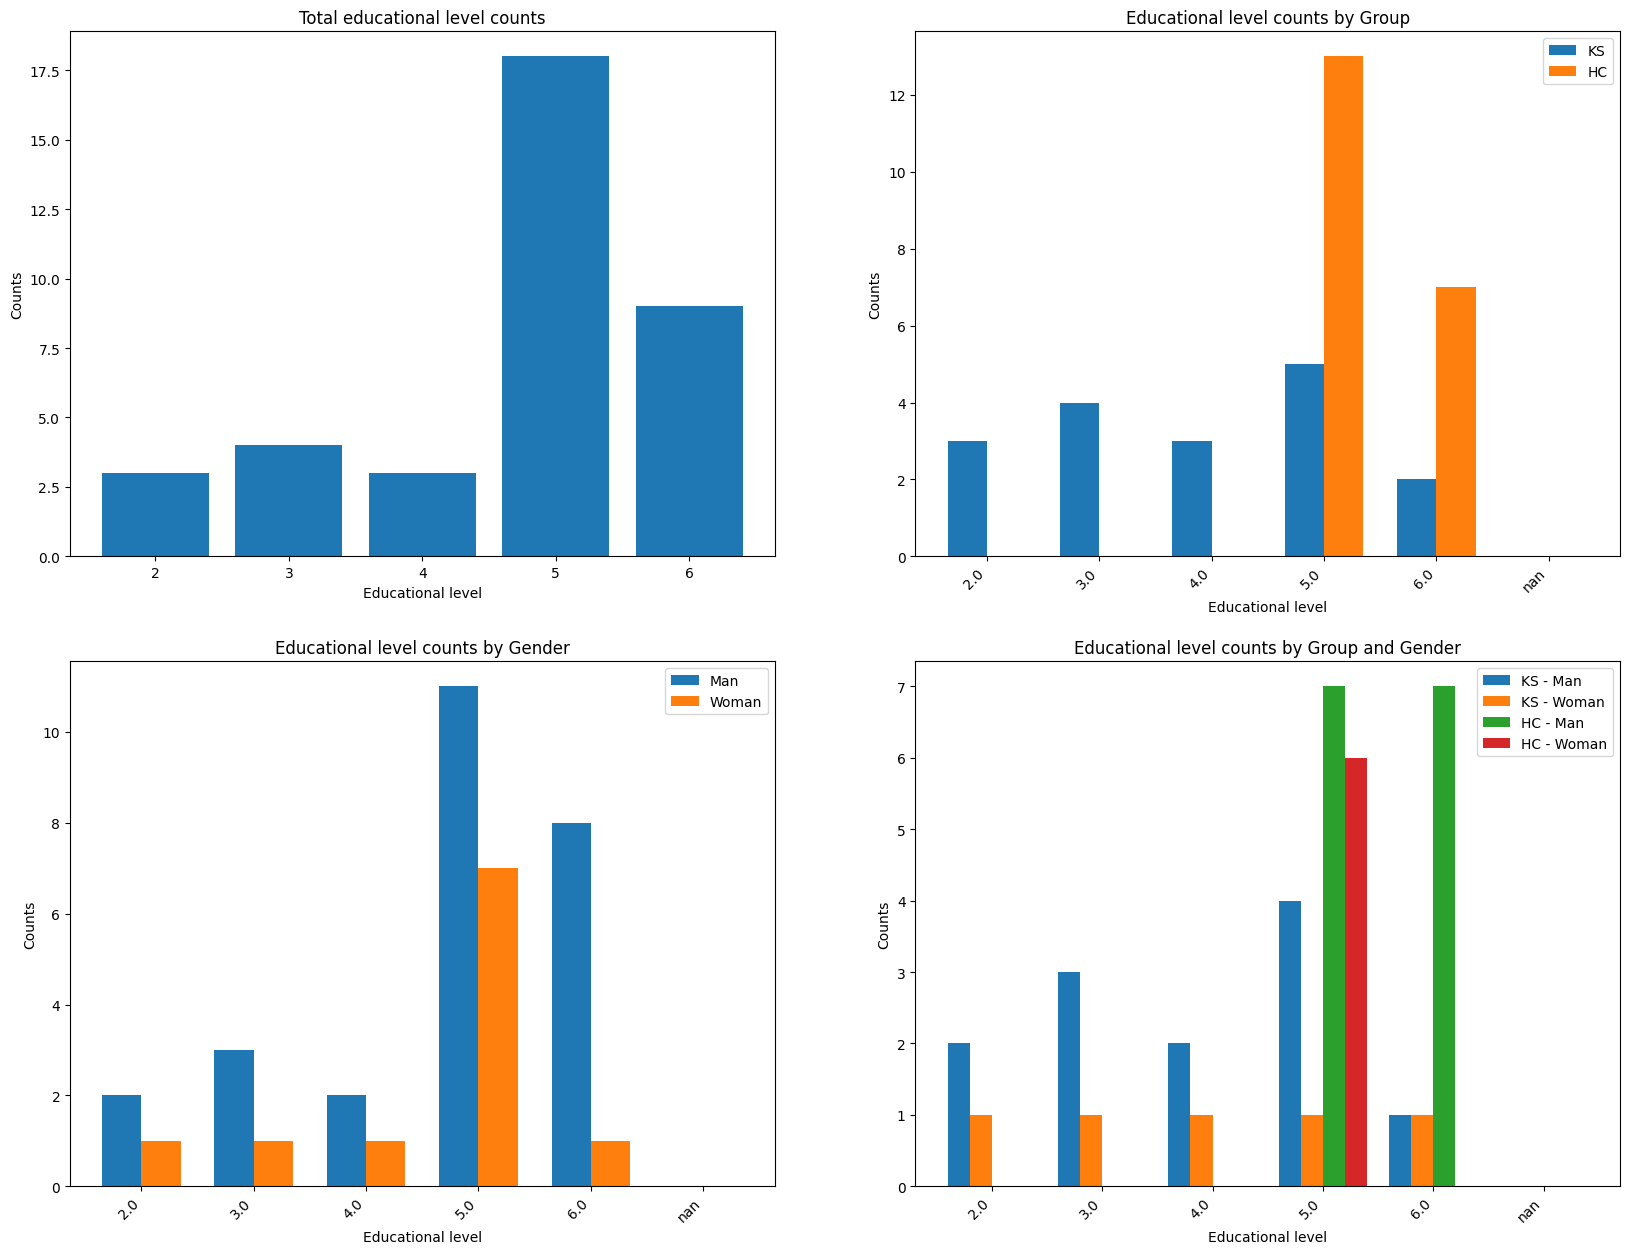

In [9]:
print("Unique values: ", len(np.unique(df["opleiding"])))
fig, ax = plt.subplots(2,2, figsize=(20, 15)) 

age_counts = df["opleiding"].value_counts().sort_index()
ax[0,0].bar(age_counts.index, age_counts.values)
ax[0,0].set_xlabel("Educational level")
ax[0,0].set_ylabel("Counts")
ax[0,0].set_title("Total educational level counts")

levels = sorted(df["opleiding"].unique())
x = np.arange(len(levels))  # positions on x-axis
width = 0.35                # width of each bar
# Split by group
counts_0 = (df[df["groep"] == 0]["opleiding"].value_counts().reindex(levels, fill_value=0))
counts_1 = (df[df["groep"] == 1]["opleiding"].value_counts().reindex(levels, fill_value=0))
ax[0,1].bar(x - width/2, counts_0.values, width, label="Group 0")
ax[0,1].bar(x + width/2, counts_1.values, width, label="Group 1")
ax[0,1].set_xlabel("Educational level")
ax[0,1].set_ylabel("Counts")
ax[0,1].set_xticks(x, levels, rotation=45, ha="right")
ax[0,1].set_title("Educational level counts by Group")
ax[0,1].legend(['KS', 'HC'])

# Split by gender
counts_0 = (df[df["sekse"] == 0]["opleiding"].value_counts().reindex(levels, fill_value=0))
counts_1 = (df[df["sekse"] == 1]["opleiding"].value_counts().reindex(levels, fill_value=0))
ax[1,0].bar(x - width/2, counts_0.values, width, label="Group 0")
ax[1,0].bar(x + width/2, counts_1.values, width, label="Group 1")
ax[1,0].set_xlabel("Educational level")
ax[1,0].set_ylabel("Counts")
ax[1,0].set_xticks(x, levels, rotation=45, ha="right")
ax[1,0].set_title("Educational level counts by Gender")
ax[1,0].legend(['Man', 'Woman'])

# Split by gender-group combintions
width = 0.2                
combinations = [(0, 0, "KS - Man"),(0, 1, "KS - Woman"),(1, 0, "HC - Man"),(1, 1, "HC - Woman"),]
for i, (groep, sekse, label) in enumerate(combinations):
    counts = (df[(df["groep"] == groep) & (df["sekse"] == sekse)]["opleiding"].value_counts().reindex(levels, fill_value=0))
    ax[1,1].bar(x + (i - 1.5) * width, counts.values, width, label=label)
ax[1,1].set_xlabel("Educational level")
ax[1,1].set_ylabel("Counts")
ax[1,1].set_xticks(x, levels, rotation=45, ha="right")
ax[1,1].set_title("Educational level counts by Group and Gender")
ax[1,1].legend()
plt.show()

## . Quantitative/scale variables

In [10]:
print("Scale: ", scale_var)

Scale:  ['leeftijd', 'RBMT', 'Stroop_k1', 'Stroop_k2', 'Stroop_k3', 'IF_Stroop', 'Tscore_IF_Stroop', 'percent_IF_Stroop', 'NLV', 'TIQ_WAIS', 'VBI_WAIS', 'PRI_WAIS', 'WG_WAIS', 'PF_LLT', 'percent_PF_LLT', 'leerind_LLT', 'percent_leerind_LLT', 'time.1', 'time.2', 'time.3', 'time.4', 'time.5', 'time.6', 'time.7', 'time.8', 'time.9', 'time.10', 'time.11', 'time.12', 'time.13', 'time.14', 'time.15', 'time.16', 'time.17', 'time.18', 'time.19', 'time.20', 'abs_err.1', 'abs_err.2', 'abs_err.3', 'abs_err.4', 'abs_err.5', 'abs_err.6', 'abs_err.7', 'abs_err.8', 'abs_err.9', 'abs_err.10', 'abs_err.11', 'abs_err.12', 'abs_err.13', 'abs_err.14', 'abs_err.15', 'abs_err.16', 'abs_err.17', 'abs_err.18', 'abs_err.19', 'abs_err.20', 'bestft.1', 'bestft.2', 'bestft.3', 'bestft.4', 'bestft.5', 'bestft.6', 'bestft.7', 'bestft.8', 'bestft.9', 'bestft.10', 'bestft.11', 'bestft.12', 'bestft.13', 'bestft.14', 'bestft.15', 'bestft.16', 'bestft.17', 'bestft.18', 'bestft.19', 'bestft.20', 'abs_err_NT', 'abs_err_si

In [11]:
df_scale = df[scale_var]
desc = df_scale.describe().T

desc["n_unique"] = df_scale.nunique()
missing_codes = [9999, 9999.00, 8888]
desc["n_missing"] = df_scale.replace(missing_codes, np.nan).isna().sum()

with pd.option_context('display.max_rows', None):
    display(desc)

,count,mean,std,min,25%,50%,75%,max,n_unique,n_missing
leeftijd,40.0,58.825000,7.030656,43.000000,54.000000,58.000000,65.000000,75.000000,20,0
RBMT,14.0,57.214286,6.435222,52.000000,54.000000,55.500000,57.750000,78.000000,10,26
Stroop_k1,38.0,57.105263,18.047669,38.000000,46.000000,51.000000,61.500000,120.000000,28,2
Stroop_k2,38.0,71.105263,21.226945,43.000000,59.500000,68.000000,77.000000,140.000000,26,2
Stroop_k3,38.0,123.894737,59.927339,66.000000,87.500000,106.000000,125.500000,350.000000,33,2
IF_Stroop,34.0,115.088235,34.563396,72.000000,94.500000,110.500000,122.250000,234.000000,29,6
Tscore_IF_Stroop,34.0,53.205882,7.853891,39.000000,47.000000,52.500000,57.000000,74.000000,19,6
percent_IF_Stroop,34.0,59.117647,23.683218,14.000000,38.000000,60.000000,76.000000,99.000000,19,6
NLV,35.0,96.857143,15.306944,67.000000,87.000000,94.000000,107.000000,129.000000,28,5
TIQ_WAIS,13.0,73.769231,10.465450,59.000000,67.000000,74.000000,79.000000,95.000000,13,27


### . Age

Unique values:  20


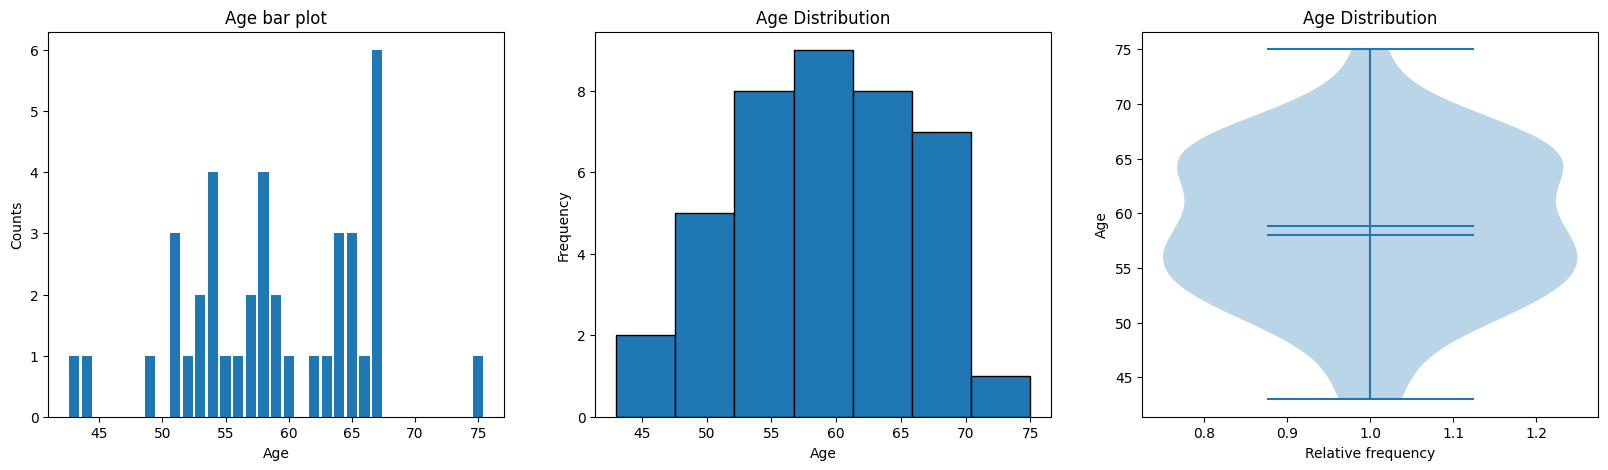

In [13]:
print("Unique values: ", len(np.unique(df["leeftijd"])))
fig, ax = plt.subplots(1,3, figsize=(20, 5)) 
# plot bar plots
age_counts = df["leeftijd"].value_counts().sort_index()
ax[0].bar(age_counts.index, age_counts.values)
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Counts")
ax[0].set_title("Age bar plot")

# plot histogram
ax[1].hist(df["leeftijd"], bins="auto", edgecolor="black")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Age Distribution")
# plot violin plot
ax[2].violinplot(df["leeftijd"], showmeans=True, showmedians=True)
ax[2].set_ylabel("Age")
ax[2].set_xlabel("Relative frequency")
ax[2].set_title("Age Distribution")
plt.show()

### . Rivermead Behavioural Memory Test (RBMT)

General Memory Index RBMT

In [17]:
# Check missing values per group 
rbmt_ks = df[df["groep"] == 0]["RBMT"]
rbmt_hc = df[df["groep"] == 1]["RBMT"]

print("KS missing values: ", rbmt_ks.replace(missing_codes, np.nan).isna().sum())
print("KS values: ", rbmt_ks.unique())
print("HC missing values: ", rbmt_hc.replace(missing_codes, np.nan).isna().sum())
print("HC values: ", rbmt_hc.unique())

KS missing values:  6
KS values:  [55. nan 58. 54. 53. 59. 56. 60. 57. 52. 78.]
HC missing values:  20
HC values:  [nan]


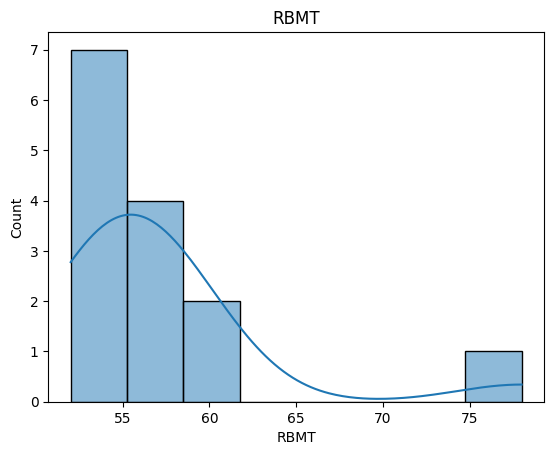

In [40]:
var = "RBMT"
data = df[var].replace(missing_codes, np.nan).dropna()
sns.histplot(data, kde=True)
plt.title(f"{var}")
plt.ylabel("Count")    
plt.show()

### . Stroop Color-Word Test (SCWT)

- Stroop_k1 : Stroop time (sec) card 1
- Stroop_k2 : Stroop time (sec) card 2
- Stroop_k3 : Stroop time (sec) card 3
- IF_Stroop : Raw interference score Stroop test
- Tscore_IF_Stroop : T-score interferentie Strooptest
- percent_IF_Stroop : Percentiel score interferentie Strooptest

In [19]:
df[['ID',"leeftijd", "opleiding", "Stroop_k1","Stroop_k2","Stroop_k3","IF_Stroop","Tscore_IF_Stroop","percent_IF_Stroop"]]

,ID,leeftijd,opleiding,Stroop_k1,Stroop_k2,Stroop_k3,IF_Stroop,Tscore_IF_Stroop,percent_IF_Stroop
0,1.0,58.0,6.0,54.0,69.0,96.0,109.0,57.0,76.0
1,2.0,65.0,3.0,104.0,132.0,350.0,NaN,NaN,NaN
2,3.0,54.0,5.0,46.0,100.0,134.0,147.0,53.0,62.0
3,4.0,58.0,5.0,60.0,79.0,110.0,125.0,56.0,73.0
4,5.0,53.0,3.0,68.0,80.0,154.0,132.0,44.0,27.0
5,6.0,64.0,2.0,60.0,77.0,113.0,123.0,54.0,66.0
6,7.0,67.0,4.0,75.0,79.0,193.0,137.0,39.0,14.0
7,8.0,52.0,NaN,65.0,63.0,122.0,NaN,NaN,NaN
8,9.0,44.0,3.0,42.0,49.0,85.0,84.0,49.0,46.0
9,10.0,58.0,NaN,56.0,65.0,103.0,117.0,56.0,73.0


In [22]:
# Check missing values per group 
variables = ["Stroop_k1","Stroop_k2","Stroop_k3","IF_Stroop","Tscore_IF_Stroop","percent_IF_Stroop"]
results = []

for var in variables:
    ks = df[df["groep"] == 0][var].replace(missing_codes, np.nan)
    hc = df[df["groep"] == 1][var].replace(missing_codes, np.nan)
    results.append({"Variable": var,"KS": ks.isna().sum(),"HC": hc.isna().sum(),\
                    "KS_unique_values": ks.unique(), "HC_unique_values": hc.unique()})

missing_table = pd.DataFrame(results).set_index("Variable")
display(missing_table)

,KS,HC,KS_unique_values,HC_unique_values
Variable,,,,
Stroop_k1,1,1,"[54.0, 104.0, 46.0, 60.0, 68.0, 75.0, 65.0, 42...","[45.0, 50.0, 43.0, 44.0, 46.0, 38.0, 47.0, 54...."
Stroop_k2,1,1,"[69.0, 132.0, 100.0, 79.0, 80.0, 77.0, 63.0, 4...","[49.0, 56.0, 59.0, 68.0, 65.0, 46.0, 70.0, 44...."
Stroop_k3,1,1,"[96.0, 350.0, 134.0, 110.0, 154.0, 113.0, 193....","[69.0, 99.0, 66.0, 75.0, 126.0, 117.0, 108.0, ..."
IF_Stroop,5,1,"[109.0, nan, 147.0, 125.0, 132.0, 123.0, 137.0...","[87.0, 96.0, 94.0, 105.0, 108.0, 77.0, 112.0, ..."
Tscore_IF_Stroop,5,1,"[57.0, nan, 53.0, 56.0, 44.0, 54.0, 39.0, 49.0...","[66.0, 49.0, 74.0, 65.0, 41.0, 46.0, 52.0, 57...."
percent_IF_Stroop,5,1,"[76.0, nan, 62.0, 73.0, 27.0, 66.0, 14.0, 46.0...","[95.0, 46.0, 99.0, 93.0, 18.0, 34.0, 58.0, 76...."


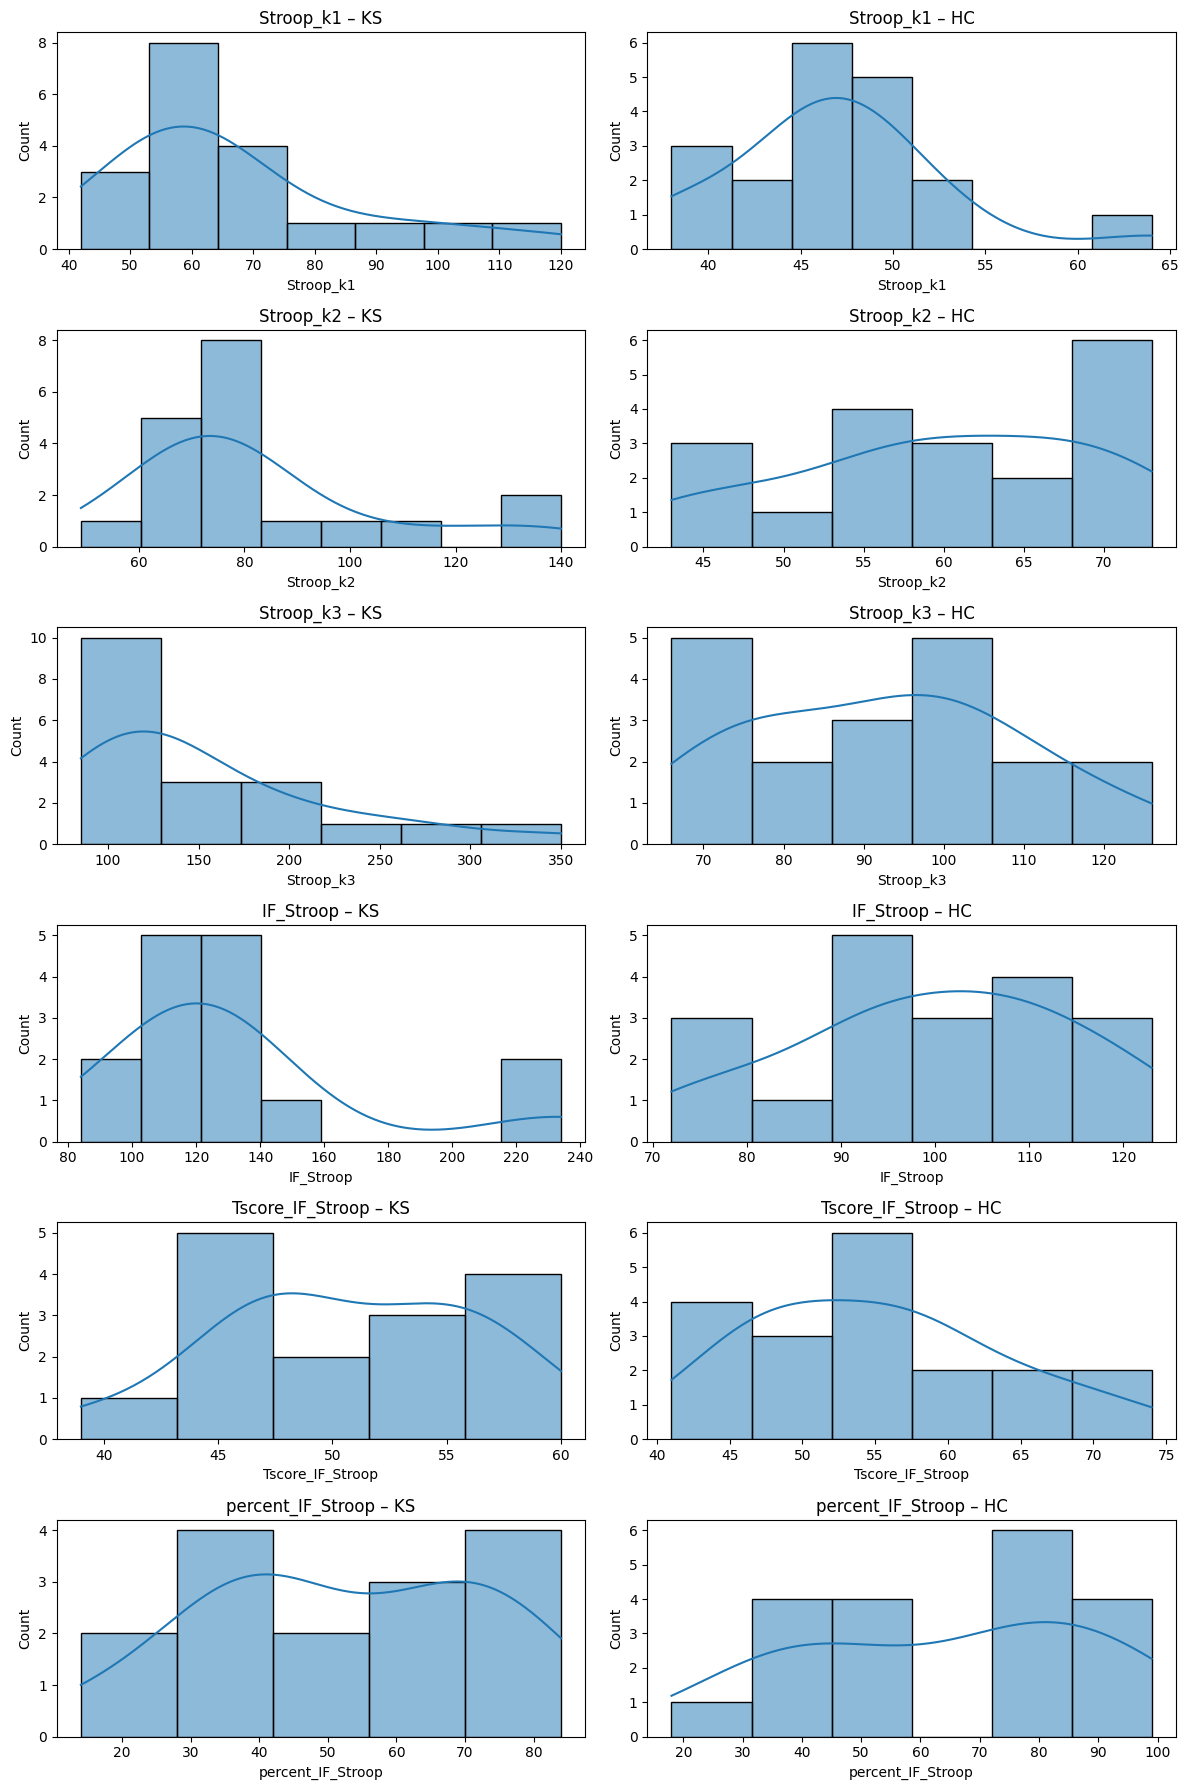

In [23]:
fig, axes = plt.subplots(nrows=len(variables),ncols=2,figsize=(12, 3 * len(variables)),sharex=False)

for i, var in enumerate(variables):
    ks = df[df["groep"] == 0][var].replace(missing_codes, np.nan).dropna()
    hc = df[df["groep"] == 1][var].replace(missing_codes, np.nan).dropna()

    # KS distribution
    sns.histplot(ks, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{var} – KS")
    axes[i, 0].set_ylabel("Count")

    # HC distribution
    sns.histplot(hc, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{var} – HC")

plt.tight_layout()
plt.show()

### . Dutch California Verbal Learning Test (NVL)

Deviatie-IQ NLV, overall capacity to acquire and retrain verbal information

In [17]:
# Check missing values per group 
nlv_ks = df[df["groep"] == 0]["NLV"]
nlv_hc = df[df["groep"] == 1]["NLV"]

print("KS missing values: ", nlv_ks.replace(missing_codes, np.nan).isna().sum())
print("KS values: ", nlv_ks.unique())
print("HC missing values: ", nlv_hc.replace(missing_codes, np.nan).isna().sum())
print("HC values: ", nlv_hc.unique())

KS missing values:  5
KS values:  [117.  nan 106.  95.  75. 107.  78.  92.  76.  90.  70.  98.  84.  67.]
HC missing values:  0
HC values:  [ 87. 104.  84. 120. 116. 102.  94. 123. 100.  92. 115. 113. 109. 129.
 107.  86.  93. 103.]


In [ ]:
df[['ID', 'NLV']]

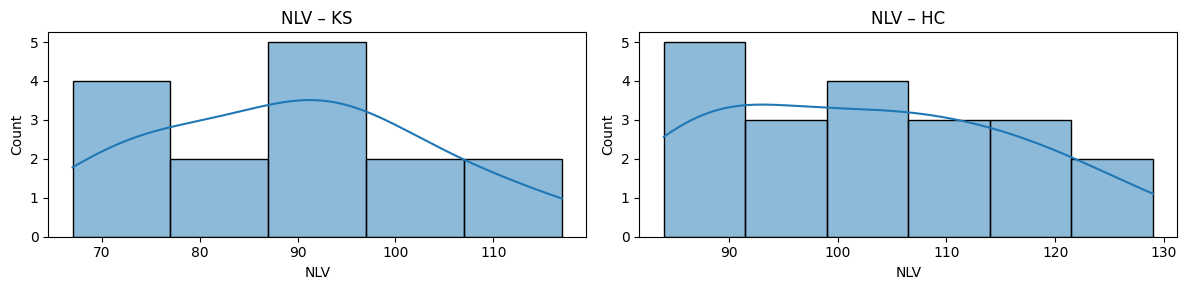

In [24]:
variables = ["NLV"]
fig, axes = plt.subplots(nrows=len(variables),ncols=2,figsize=(12, 3 * len(variables)),sharex=False)

for i, var in enumerate(variables):
    ks = df[df["groep"] == 0][var].replace(missing_codes, np.nan).dropna()
    hc = df[df["groep"] == 1][var].replace(missing_codes, np.nan).dropna()

    # KS distribution
    sns.histplot(ks, kde=True, ax=axes[0])
    axes[0].set_title(f"{var} – KS")
    axes[0].set_ylabel("Count")

    # HC distribution
    sns.histplot(hc, kde=True, ax=axes[1])
    axes[1].set_title(f"{var} – HC")

plt.tight_layout()
plt.show()

### . Wechsler Adult Intelligence Scale (WAIS-IV)

In [27]:
# Check missing values per group 
variables = ["TIQ_WAIS","VBI_WAIS","PRI_WAIS","WG_WAIS"]
results = []

for var in variables:
    ks = df[df["groep"] == 0][var].replace(missing_codes, np.nan)
    hc = df[df["groep"] == 1][var].replace(missing_codes, np.nan)
    results.append({"Variable": var,"KS": ks.isna().sum(),"HC": hc.isna().sum(),\
                    "KS_unique_values": ks.unique(), "HC_unique_values": hc.unique()})

missing_table = pd.DataFrame(results).set_index("Variable")
display(missing_table)

,KS,HC,KS_unique_values,HC_unique_values
Variable,,,,
TIQ_WAIS,7,20,"[95.0, nan, 74.0, 72.0, 81.0, 64.0, 79.0, 88.0...",[nan]
VBI_WAIS,6,20,"[116.0, nan, 74.0, 83.0, 100.0, 70.0, 86.0, 91...",[nan]
PRI_WAIS,6,20,"[85.0, nan, 68.0, 77.0, 69.0, 72.0, 83.0, 94.0...",[nan]
WG_WAIS,6,20,"[112.0, nan, 100.0, 83.0, 105.0, 74.0, 103.0, ...",[nan]


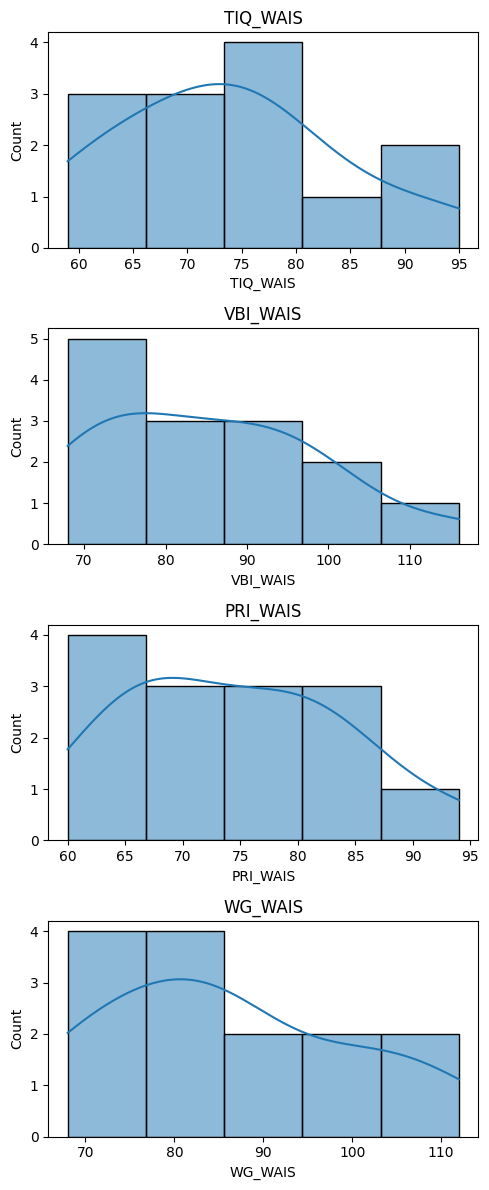

In [30]:
fig, axes = plt.subplots(nrows=len(variables),ncols=1,figsize=(5, 3 * len(variables)),sharex=False)

for i, var in enumerate(variables):
    data = df[var].replace(missing_codes, np.nan).dropna()
    sns.histplot(data, kde=True, ax=axes[i])
    axes[i].set_title(f"{var}")
    axes[i].set_ylabel("Count")
    
plt.tight_layout()
plt.show()

### . Location Learning Test (LLT)


- PF_LLT: Total placement errors location learning test
- percent_PF_LLT : Percentile score total PF location learning test
- leerind_LLT : Learning index location learning test
- percent_leerind_LLT : Percentile score learning index location learning test

In [41]:
# Check missing values per group 
variables = ["PF_LLT","percent_PF_LLT","leerind_LLT","percent_leerind_LLT"]
results = []

for var in variables:
    ks = df[df["groep"] == 0][var].replace(missing_codes, np.nan)
    hc = df[df["groep"] == 1][var].replace(missing_codes, np.nan)
    results.append({"Variable": var,"KS": ks.isna().sum(),"HC": hc.isna().sum(),\
                    "KS_unique_values": ks.unique(), "HC_unique_values": hc.unique()})

missing_table = pd.DataFrame(results).set_index("Variable")
display(missing_table)

,KS,HC,KS_unique_values,HC_unique_values
Variable,,,,
PF_LLT,7,20,"[125.0, nan, 60.0, 119.0, 83.0, 70.0, 67.0, 98...",[nan]
percent_PF_LLT,7,20,"[1.0, nan, 4.0, 13.0, 2.0, 5.0]",[nan]
leerind_LLT,7,20,"[0.05, nan, 0.105, 0.07, 0.12, 0.14, 0.195, 0....",[nan]
percent_leerind_LLT,7,20,"[1.0, nan, 4.0, 18.0, 2.0, 13.0, 8.0]",[nan]


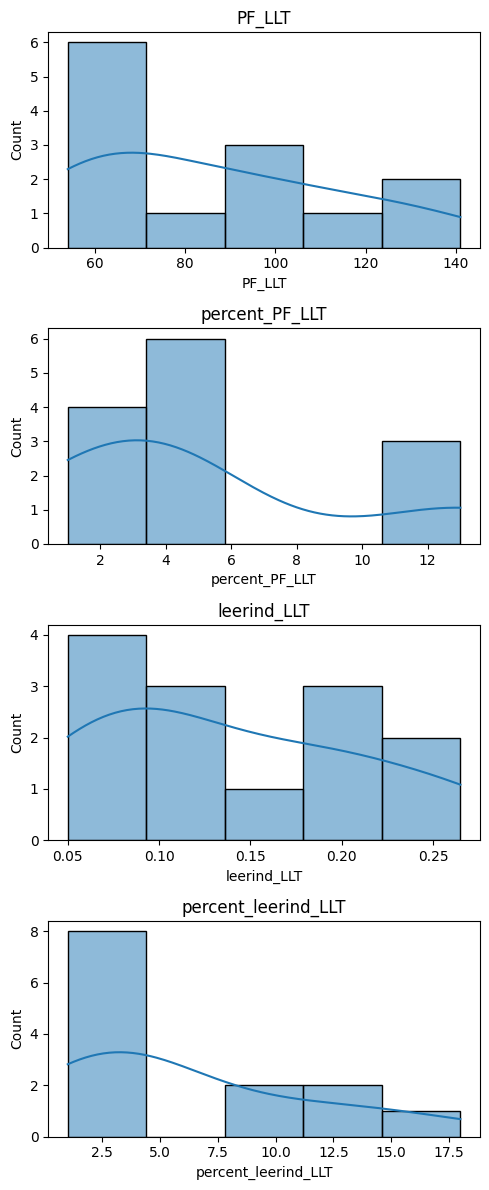

In [42]:
fig, axes = plt.subplots(nrows=len(variables),ncols=1,figsize=(5, 3 * len(variables)),sharex=False)

for i, var in enumerate(variables):
    data = df[var].replace(missing_codes, np.nan).dropna()
    sns.histplot(data, kde=True, ax=axes[i])
    axes[i].set_title(f"{var}")
    axes[i].set_ylabel("Count")
    
plt.tight_layout()
plt.show()